# TP1 — FashionMNIST : CNN, DenseNet et Transfer Learning
**Projet de fin de module — Deep Learning**

Objectifs (d'après l'énoncé et l'Issue #1 du dépôt du professeur) :
1. Construire un **CNN « maison »** pour classer FashionMNIST (10 classes).
2. Utiliser un **DenseNet** pré-entraîné (transfer learning).
3. Adapter **AlexNet / ResNet18 / VGG16** pré-entraînés sur ImageNet au dataset
   FashionMNIST et **comparer les stratégies de gel des couches** :
   - peu de données  -> geler tout sauf la dernière couche (extraction de features) ;
   - assez de données -> ne geler que les premières couches ;
   - meilleur résultat -> fine-tuning progressif (dégel progressif).

> Exécuter de préférence sur **Google Colab** avec un GPU
> (Menu *Exécution > Modifier le type d'exécution > T4 GPU*).

## 0. Imports et configuration

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix

import os
os.makedirs("figs", exist_ok=True)        # les figures du rapport y seront enregistrees

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

# --- Hyper-parametres (reduire SUBSET_* ou EPOCHS_* si le GPU est limite) ---
BATCH          = 64
IMG_SIZE       = 224     # taille attendue par les modeles pre-entraines ImageNet
SUBSET_TRAIN   = 8000    # sous-echantillon pour le transfer learning (compute raisonnable)
SUBSET_TEST    = 2000
EPOCHS_CNN     = 8       # CNN maison (donnees completes, 28x28 -> rapide)
EPOCHS_TL      = 5       # transfer learning
SEED           = 42
torch.manual_seed(SEED)

classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Device : cuda


## 1. Fonctions utilitaires d'entraînement et d'évaluation
Une seule paire de fonctions est réutilisée pour tous les modèles, ce qui rend
la comparaison équitable.

In [2]:
def evaluate(model, loader, criterion=None):
    """Retourne (loss moyenne, accuracy %) sur un DataLoader."""
    model.eval()
    criterion = criterion or nn.CrossEntropyLoss()
    tot_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            tot_loss += criterion(out, y).item() * X.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            n += X.size(0)
    return tot_loss / n, 100.0 * correct / n


def train_model(model, train_loader, val_loader, epochs, lr=1e-3, optimizer=None):
    """Boucle d'entraînement generique. Retourne l'historique et le temps total."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        # on n'optimise que les parametres non geles
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        run_loss, correct, n = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * X.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            n += X.size(0)
        vl, va = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(run_loss / n)
        hist["train_acc"].append(100.0 * correct / n)
        hist["val_loss"].append(vl)
        hist["val_acc"].append(va)
        print(f"  Epoch {epoch+1:2d}/{epochs} | train_loss {run_loss/n:.4f} "
              f"acc {100.0*correct/n:5.2f}% | val_loss {vl:.4f} acc {va:5.2f}%")
    return hist, time.time() - t0


def get_predictions(model, loader):
    """Retourne (y_true, y_pred) en numpy pour la matrice de confusion."""
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            ps.append(model(X).argmax(1).cpu())
            ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

## 2. Partie A — CNN « maison » (baseline)
Données brutes 28×28 en niveaux de gris, normalisées. Architecture : 2 blocs
convolutifs (Conv → BatchNorm → ReLU → MaxPool) puis un classifieur dense avec Dropout.

In [3]:
tf_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),   # moyenne/ecart-type de FashionMNIST
])

train_base = torchvision.datasets.FashionMNIST(root="data", train=True,  download=True, transform=tf_base)
test_base  = torchvision.datasets.FashionMNIST(root="data", train=False, download=True, transform=tf_base)

train_loader_base = DataLoader(train_base, batch_size=BATCH, shuffle=True,  num_workers=2)
test_loader_base  = DataLoader(test_base,  batch_size=BATCH, shuffle=False, num_workers=2)

print(f"Train: {len(train_base)} images | Test: {len(test_base)} images")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.1MB/s]

Train: 60000 images | Test: 10000 images


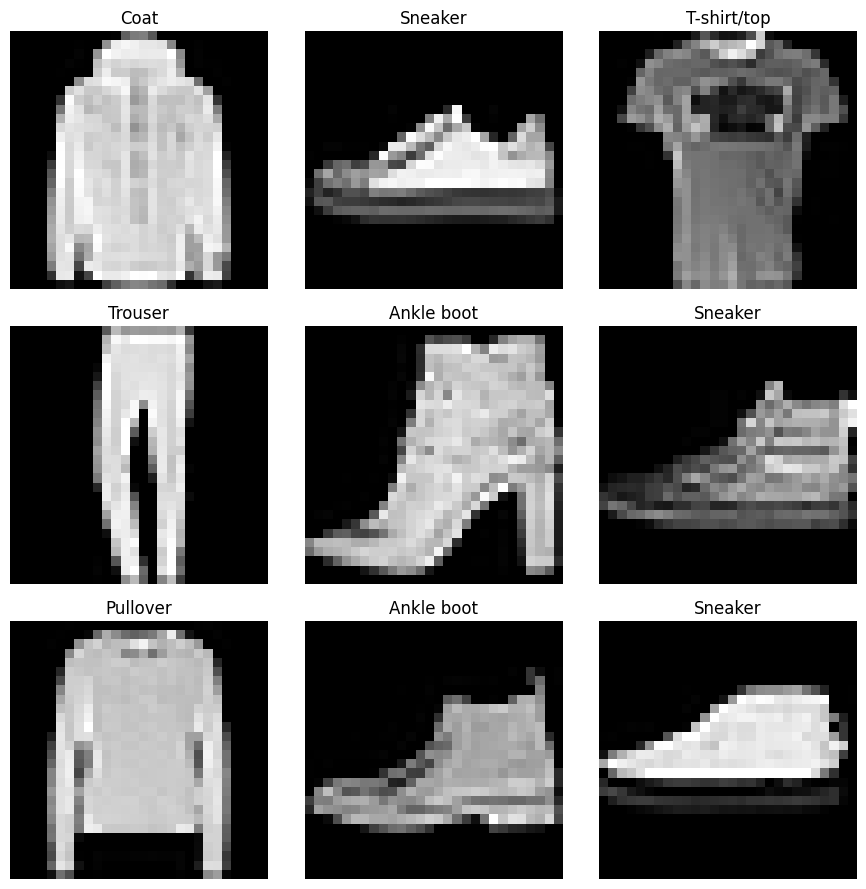

In [4]:
# Apercu de quelques images (figure du rapport : figures/tp1_samples.png)
fig = plt.figure(figsize=(9, 9))
for i in range(9):
    img, label = train_base[np.random.randint(len(train_base))]
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[label]); plt.axis("off")
plt.tight_layout()
plt.savefig("figs/tp1_samples.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
class FashionCNN(nn.Module):
    """CNN simple : 2 blocs conv (BatchNorm + ReLU + MaxPool) + classifieur dense."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                   # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn = FashionCNN().to(device)
print(cnn)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
print("Entrainement du CNN maison :")
hist_cnn, t_cnn = train_model(cnn, train_loader_base, test_loader_base, EPOCHS_CNN, lr=1e-3)

Entrainement du CNN maison :
  Epoch  1/8 | train_loss 0.3993 acc 85.46% | val_loss 0.3009 acc 88.67%
  Epoch  2/8 | train_loss 0.2758 acc 89.93% | val_loss 0.2638 acc 90.50%
  Epoch  3/8 | train_loss 0.2350 acc 91.31% | val_loss 0.2502 acc 90.46%
  Epoch  4/8 | train_loss 0.2074 acc 92.20% | val_loss 0.2444 acc 91.43%
  Epoch  5/8 | train_loss 0.1849 acc 93.11% | val_loss 0.2303 acc 91.85%
  Epoch  6/8 | train_loss 0.1637 acc 93.85% | val_loss 0.2357 acc 91.71%
  Epoch  7/8 | train_loss 0.1473 acc 94.48% | val_loss 0.2326 acc 92.10%
  Epoch  8/8 | train_loss 0.1292 acc 95.20% | val_loss 0.2397 acc 92.32%


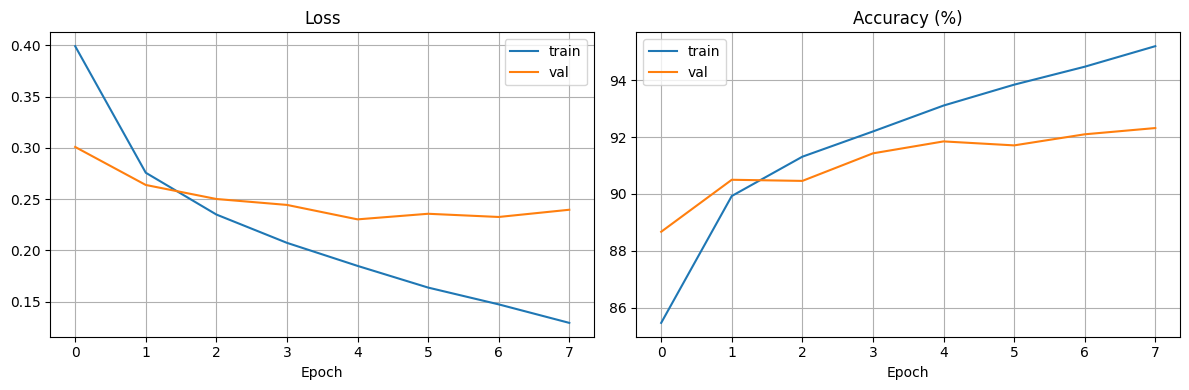

In [7]:
# Courbes d'apprentissage (figure : figures/tp1_cnn_curves.png)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_cnn["train_loss"], label="train"); ax[0].plot(hist_cnn["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(hist_cnn["train_acc"], label="train"); ax[1].plot(hist_cnn["val_acc"], label="val")
ax[1].set_title("Accuracy (%)"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout()
plt.savefig("figs/tp1_cnn_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Rapport de classification du CNN maison
y_true, y_pred = get_predictions(cnn, test_loader_base)
print(classification_report(y_true, y_pred, target_names=classes))

results = {}   # on accumule les resultats pour le tableau comparatif final
tot, tr = count_params(cnn)
results["CNN maison"] = {"acc": evaluate(cnn, test_loader_base)[1],
                         "params_total": tot, "params_trainable": tr,
                         "strategie": "-", "temps_s": round(t_cnn, 1)}

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.91      0.88      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.90      0.87      0.88      1000
       Dress       0.94      0.91      0.92      1000
        Coat       0.86      0.91      0.88      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.78      0.76      0.77      1000
     Sneaker       0.94      0.99      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 3. Partie B — Pipeline pour modèles pré-entraînés
Les modèles ImageNet attendent des images **RGB 224×224** normalisées avec les
moyennes/écarts-types d'ImageNet. FashionMNIST étant en **niveaux de gris 28×28**,
on convertit en 3 canaux, on redimensionne en 224, puis on normalise.
Pour garder un temps de calcul raisonnable sur Colab, on travaille sur un
**sous-échantillon** (ce qui illustre aussi le régime « peu de données »).

In [9]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

tf_pre = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),       # 1 canal -> 3 canaux
    transforms.Resize((IMG_SIZE, IMG_SIZE)),           # 28x28 -> 224x224
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std), # normalisation ImageNet
])

train_pre = torchvision.datasets.FashionMNIST(root="data", train=True,  download=True, transform=tf_pre)
test_pre  = torchvision.datasets.FashionMNIST(root="data", train=False, download=True, transform=tf_pre)

g = torch.Generator().manual_seed(SEED)
idx_tr = torch.randperm(len(train_pre), generator=g)[:SUBSET_TRAIN].tolist()
idx_te = torch.randperm(len(test_pre),  generator=g)[:SUBSET_TEST].tolist()
train_sub = Subset(train_pre, idx_tr)
test_sub  = Subset(test_pre,  idx_te)

train_loader_pre = DataLoader(train_sub, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader_pre  = DataLoader(test_sub,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"Sous-echantillon -> Train: {len(train_sub)} | Test: {len(test_sub)}")
img0, _ = train_sub[0]
print("Forme d'une image transformee :", tuple(img0.shape))   # (3, 224, 224)

Sous-echantillon -> Train: 8000 | Test: 2000
Forme d'une image transformee : (3, 224, 224)


## 4. Partie C — Fabrique de modèles et stratégies de gel
`strategy` :
- `freeze_all`   : tout le backbone gelé, on n'entraîne que la nouvelle tête (extraction de features) ;
- `freeze_early` : seules les premières couches sont gelées ;
- `finetune`     : tout est entraînable (utilisé pour la phase 2 du fine-tuning progressif).

In [10]:
def _apply_freeze(model, strategy):
    params = list(model.parameters())
    if strategy == "freeze_all":
        for p in params:
            p.requires_grad = False
    elif strategy == "freeze_early":
        cut = len(params) // 2          # on gele la premiere moitie des parametres
        for i, p in enumerate(params):
            p.requires_grad = (i >= cut)
    elif strategy == "finetune":
        for p in params:
            p.requires_grad = True
    else:
        raise ValueError(f"strategie inconnue : {strategy}")


def build_model(name, num_classes=10, strategy="freeze_all", pretrained=True):
    """Charge un modele pre-entraine, applique la strategie de gel,
    puis remplace la derniere couche par une couche a `num_classes` sorties
    (cette nouvelle couche est toujours entrainable)."""
    name = name.lower()
    if name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        in_f = m.classifier.in_features
        _apply_freeze(m, strategy)
        m.classifier = nn.Linear(in_f, num_classes)
    elif name == "alexnet":
        m = models.alexnet(weights=models.AlexNet_Weights.DEFAULT if pretrained else None)
        in_f = m.classifier[6].in_features
        _apply_freeze(m, strategy)
        m.classifier[6] = nn.Linear(in_f, num_classes)
    elif name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        in_f = m.fc.in_features
        _apply_freeze(m, strategy)
        m.fc = nn.Linear(in_f, num_classes)
    elif name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT if pretrained else None)
        in_f = m.classifier[6].in_features
        _apply_freeze(m, strategy)
        m.classifier[6] = nn.Linear(in_f, num_classes)
    else:
        raise ValueError(f"modele inconnu : {name}")
    return m

## 5. Partie D — DenseNet121 (extraction de features)
On gèle tout le backbone DenseNet et on n'entraîne que la nouvelle couche de classification.

In [11]:
densenet = build_model("densenet121", strategy="freeze_all")
tot, tr = count_params(densenet)
print(f"DenseNet121 -> parametres totaux {tot:,} | entrainables {tr:,}")
hist_dn, t_dn = train_model(densenet, train_loader_pre, test_loader_pre, EPOCHS_TL, lr=1e-3)
results["DenseNet121 (gel total)"] = {"acc": evaluate(densenet, test_loader_pre)[1],
                                      "params_total": tot, "params_trainable": tr,
                                      "strategie": "freeze_all", "temps_s": round(t_dn, 1)}

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 137MB/s]


DenseNet121 -> parametres totaux 6,964,106 | entrainables 10,250
  Epoch  1/5 | train_loss 1.1411 acc 66.58% | val_loss 0.7110 acc 78.50%
  Epoch  2/5 | train_loss 0.6510 acc 79.15% | val_loss 0.5689 acc 81.05%
  Epoch  3/5 | train_loss 0.5446 acc 82.21% | val_loss 0.5127 acc 83.20%
  Epoch  4/5 | train_loss 0.4983 acc 83.24% | val_loss 0.4926 acc 83.05%
  Epoch  5/5 | train_loss 0.4676 acc 83.75% | val_loss 0.4729 acc 83.80%


## 6. Partie E — Comparaison AlexNet / ResNet18 / VGG16 (extraction de features)
Même protocole pour les trois modèles : backbone gelé, seule la tête est ré-entraînée.

In [12]:
tl_histories = {}
for name in ["alexnet", "resnet18", "vgg16"]:
    print(f"\n=== {name} (freeze_all) ===")
    m = build_model(name, strategy="freeze_all")
    tot, tr = count_params(m)
    h, t = train_model(m, train_loader_pre, test_loader_pre, EPOCHS_TL, lr=1e-3)
    tl_histories[name] = h
    results[f"{name} (gel total)"] = {"acc": evaluate(m, test_loader_pre)[1],
                                      "params_total": tot, "params_trainable": tr,
                                      "strategie": "freeze_all", "temps_s": round(t, 1)}


=== alexnet (freeze_all) ===
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 180MB/s]


  Epoch  1/5 | train_loss 0.7123 acc 74.53% | val_loss 0.5000 acc 81.50%
  Epoch  2/5 | train_loss 0.5379 acc 80.26% | val_loss 0.4402 acc 83.25%
  Epoch  3/5 | train_loss 0.4860 acc 81.99% | val_loss 0.4625 acc 82.80%
  Epoch  4/5 | train_loss 0.4793 acc 82.31% | val_loss 0.4290 acc 84.30%
  Epoch  5/5 | train_loss 0.4521 acc 83.20% | val_loss 0.4203 acc 84.50%

=== resnet18 (freeze_all) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


  Epoch  1/5 | train_loss 1.1351 acc 66.44% | val_loss 0.6599 acc 80.20%
  Epoch  2/5 | train_loss 0.6270 acc 79.85% | val_loss 0.5474 acc 81.95%
  Epoch  3/5 | train_loss 0.5318 acc 81.88% | val_loss 0.4954 acc 82.50%
  Epoch  4/5 | train_loss 0.4948 acc 83.17% | val_loss 0.4826 acc 83.20%
  Epoch  5/5 | train_loss 0.4623 acc 83.94% | val_loss 0.4608 acc 83.45%

=== vgg16 (freeze_all) ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.5MB/s]


  Epoch  1/5 | train_loss 0.7785 acc 72.46% | val_loss 0.5280 acc 81.65%
  Epoch  2/5 | train_loss 0.5535 acc 79.67% | val_loss 0.4818 acc 82.25%
  Epoch  3/5 | train_loss 0.5284 acc 80.36% | val_loss 0.4461 acc 84.30%
  Epoch  4/5 | train_loss 0.5086 acc 81.53% | val_loss 0.4430 acc 84.00%
  Epoch  5/5 | train_loss 0.4920 acc 81.97% | val_loss 0.4305 acc 85.05%


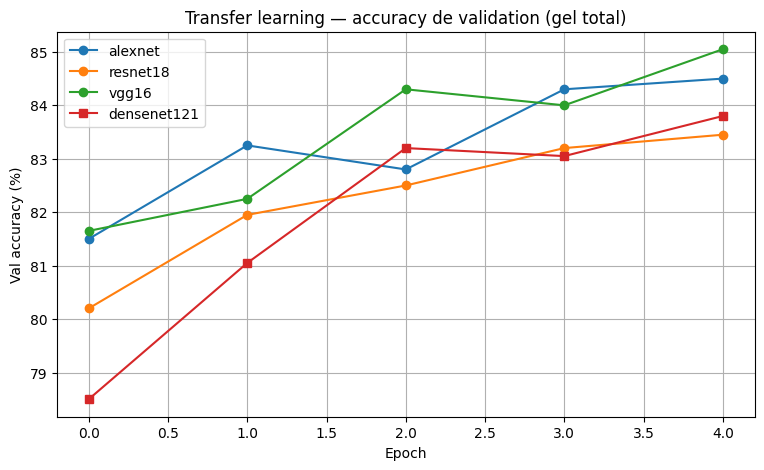

In [13]:
# Comparaison des courbes de val accuracy (figure : figures/tp1_tl_comparison.png)
plt.figure(figsize=(9, 5))
for name, h in tl_histories.items():
    plt.plot(h["val_acc"], marker="o", label=name)
plt.plot(hist_dn["val_acc"], marker="s", label="densenet121")
plt.title("Transfer learning — accuracy de validation (gel total)")
plt.xlabel("Epoch"); plt.ylabel("Val accuracy (%)"); plt.legend(); plt.grid(True)
plt.savefig("figs/tp1_tl_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Partie F — Fine-tuning progressif (ResNet18)
Stratégie en deux phases :
1. on entraîne d'abord uniquement la tête (backbone gelé) ;
2. on dégèle tout le réseau et on poursuit avec un **taux d'apprentissage faible**
   pour affiner les couches profondes sans détruire les features pré-entraînées.

In [14]:
res = build_model("resnet18", strategy="freeze_all")
print("Phase 1 — entrainement de la tete seule :")
h_p1, t_p1 = train_model(res, train_loader_pre, test_loader_pre, EPOCHS_TL, lr=1e-3)

print("\nPhase 2 — degel complet, lr faible :")
for p in res.parameters():
    p.requires_grad = True
opt_ft = optim.Adam(res.parameters(), lr=1e-5)
h_p2, t_p2 = train_model(res, train_loader_pre, test_loader_pre, EPOCHS_TL, optimizer=opt_ft)

tot, tr = count_params(res)
results["resnet18 (fine-tuning progressif)"] = {"acc": evaluate(res, test_loader_pre)[1],
                                                "params_total": tot, "params_trainable": tr,
                                                "strategie": "progressif", "temps_s": round(t_p1 + t_p2, 1)}

Phase 1 — entrainement de la tete seule :
  Epoch  1/5 | train_loss 1.1560 acc 64.89% | val_loss 0.6764 acc 80.20%
  Epoch  2/5 | train_loss 0.6333 acc 79.45% | val_loss 0.5425 acc 81.80%
  Epoch  3/5 | train_loss 0.5441 acc 81.54% | val_loss 0.4947 acc 83.50%
  Epoch  4/5 | train_loss 0.4973 acc 82.97% | val_loss 0.4733 acc 83.05%
  Epoch  5/5 | train_loss 0.4659 acc 83.99% | val_loss 0.4520 acc 83.70%

Phase 2 — degel complet, lr faible :
  Epoch  1/5 | train_loss 0.3740 acc 87.08% | val_loss 0.3487 acc 87.50%
  Epoch  2/5 | train_loss 0.2572 acc 91.29% | val_loss 0.3161 acc 89.20%
  Epoch  3/5 | train_loss 0.1846 acc 94.40% | val_loss 0.2994 acc 89.40%
  Epoch  4/5 | train_loss 0.1405 acc 96.30% | val_loss 0.2911 acc 89.70%
  Epoch  5/5 | train_loss 0.1020 acc 97.86% | val_loss 0.2826 acc 90.05%


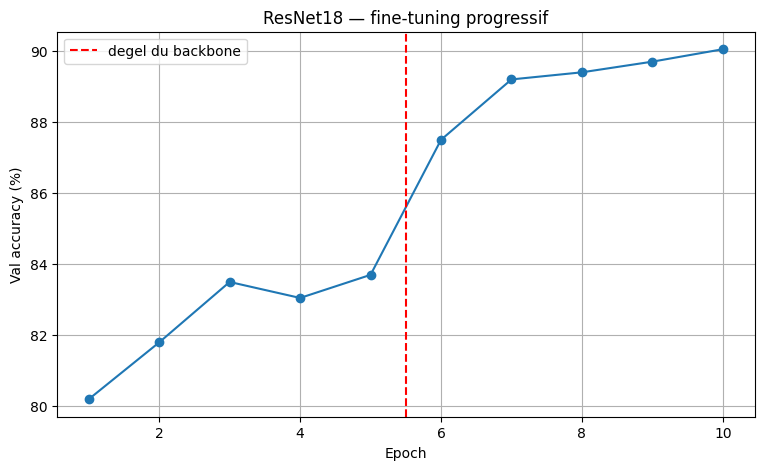

In [15]:
# Courbe du fine-tuning progressif (figure : figures/tp1_progressive.png)
acc_prog = h_p1["val_acc"] + h_p2["val_acc"]
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(acc_prog) + 1), acc_prog, marker="o")
plt.axvline(EPOCHS_TL + 0.5, color="r", ls="--", label="degel du backbone")
plt.title("ResNet18 — fine-tuning progressif")
plt.xlabel("Epoch"); plt.ylabel("Val accuracy (%)"); plt.legend(); plt.grid(True)
plt.savefig("figs/tp1_progressive.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Partie G — Évaluation finale et tableau comparatif
Matrice de confusion du meilleur modèle, puis synthèse de tous les modèles.

Meilleur modele : CNN maison (92.32%)


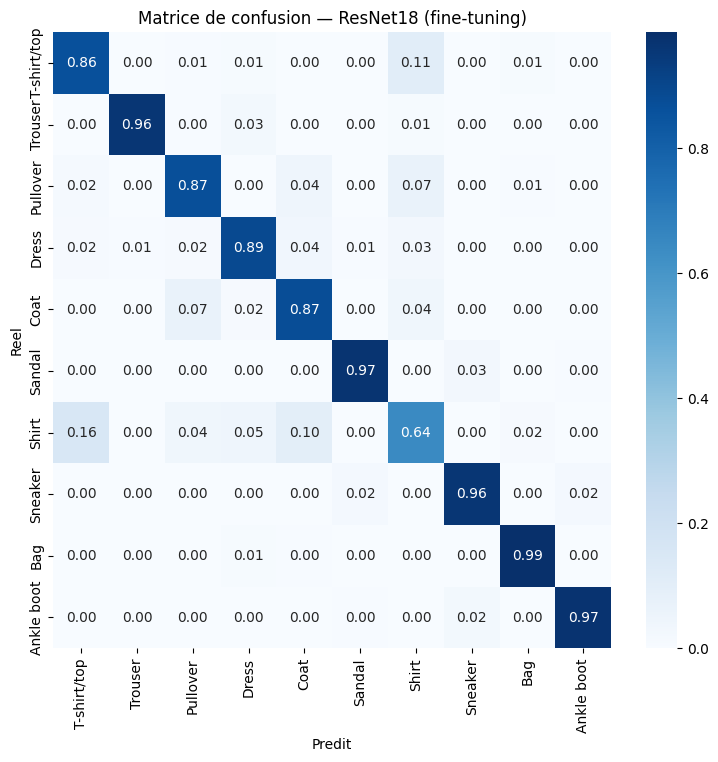

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.86      0.83       174
     Trouser       1.00      0.96      0.98       226
    Pullover       0.86      0.87      0.86       187
       Dress       0.89      0.89      0.89       195
        Coat       0.83      0.87      0.85       199
      Sandal       0.97      0.97      0.97       205
       Shirt       0.73      0.64      0.68       199
     Sneaker       0.95      0.96      0.95       205
         Bag       0.97      0.99      0.98       201
  Ankle boot       0.98      0.97      0.97       209

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



In [16]:
# Meilleur modele = celui avec la meilleure accuracy
best_name = max(results, key=lambda k: results[k]["acc"])
print("Meilleur modele :", best_name, f"({results[best_name]['acc']:.2f}%)")

# Matrice de confusion du ResNet18 fine-tune (modele de reference du TP)
y_true, y_pred = get_predictions(res, test_loader_pre)
cm = confusion_matrix(y_true, y_pred)
cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predit"); plt.ylabel("Reel"); plt.title("Matrice de confusion — ResNet18 (fine-tuning)")
plt.savefig("figs/tp1_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

In [17]:
# Tableau comparatif final
import pandas as pd
df = pd.DataFrame(results).T
df = df[["acc", "params_total", "params_trainable", "strategie", "temps_s"]]
df["acc"] = df["acc"].astype(float).round(2)
print(df.to_string())
df.to_csv("figs/tp1_results.csv")

                                     acc params_total params_trainable   strategie temps_s
CNN maison                         92.32       824650           824650           -   130.8
DenseNet121 (gel total)            83.80      6964106            10250  freeze_all   162.9
alexnet (gel total)                84.50     57044810            40970  freeze_all    85.8
resnet18 (gel total)               83.45     11181642             5130  freeze_all    92.1
vgg16 (gel total)                  85.05    134301514            40970  freeze_all   248.0
resnet18 (fine-tuning progressif)  90.05     11181642         11181642  progressif   231.1
